# LangGraph: Map-Reduce Agent with Send API

This notebook demonstrates a Map-Reduce architecture using LangGraph's `Send` API. It features a planner that generates dynamic research queries, fans them out to parallel researchers, and synthesizes the results into a final report.

### Key Concepts:
- **StateGraph**: Manages the flow of the application.
- **Send API**: Enables dynamic fan-out (Map step).
- **Conditional Edges**: Routes the workflow based on state.
- **Streaming**: Real-time feedback from the execution.

## 1. Setup and Initialization

Import necessary libraries and load environment variables (specifically `OPENAI_API_KEY`).

In [1]:
import operator
import asyncio
from typing import Annotated, List, TypedDict
from dotenv import load_dotenv

load_dotenv()

from pydantic import BaseModel, Field
from langgraph.graph import StateGraph, START, END
from langgraph.types import Send
from langchain_community.tools import DuckDuckGoSearchRun
from langchain_openai import ChatOpenAI
from langchain_core.messages import SystemMessage, HumanMessage

# Initialize LLM
llm = ChatOpenAI(model="gpt-4o-mini", temperature=0)

## 2. Define State and Models

- **ResearchPlan**: Structured output for the planner to ensure valid queries.
- **GlobalState**: Tracks the topic, the generated queries, collected findings, and the final report.

In [2]:
# Define Structured Output for the Planner
class ResearchPlan(BaseModel):
    queries: List[str] = Field(description="List of 3 specific search queries")

# Define the Graph State
class GlobalState(TypedDict):
    topic: str
    queries: List[str] # Added to persist plan across nodes
    findings: Annotated[List[str], operator.add] # Reducer collects findings
    report: str

## 3. Node Definitions

- **Analyst Planner**: Generates a research plan (3 queries).
- **Assign Researchers**: Conditional logic to fan-out tasks.
- **Researcher**: Performs a web search for a specific query.
- **Analyst Synthesizer**: Aggregates all findings into a final report.

In [3]:
# Analyst Planner: Generates sub-queries
def analyst_planner(state: GlobalState):
    print(f"--- Planning research for: {state['topic']} ---")
    # Logic: Use LLM with .with_structured_output(ResearchPlan)
    planner = llm.with_structured_output(ResearchPlan)
    
    prompt = f"Generate 3 distinct search queries to research the topic: {state['topic']}."
    plan = planner.invoke(prompt)
    
    # Return the plan to update the state
    return {"queries": plan.queries}

# Conditional Logic: Fan out
def assign_researchers(state: GlobalState):
    # Map step: spawn one researcher per query
    return [Send("researcher", {"query": q}) for q in state["queries"]]

# Researcher Node: Processes a single task
def researcher(state: dict):
    print(f"--- Investigating: {state['query']} ---")
    search = DuckDuckGoSearchRun()
    try:
        # Simple retry or safe execution
        result = search.run(state["query"])
    except Exception as e:
        result = f"Error searching for {state['query']}: {e}"
        
    return {"findings": [f"Source ({state['query']}):\n{result}\n"]}

# Analyst Synthesizer: Reduce step to aggregate results
def analyst_synthesizer(state: GlobalState):
    print("--- Synthesizing Report ---")
    combined_findings = "\n\n".join(state["findings"])
    
    # Logic: LLM generates final report from combined_findings
    messages = [
        SystemMessage(content="You are a senior analyst. Synthesize the following research findings into a comprehensive report."),
        HumanMessage(content=f"Topic: {state['topic']}\n\nFindings:\n{combined_findings}")
    ]
    response = llm.invoke(messages)
    return {"report": response.content}

## 4. Graph Construction

Assemble the nodes and edges. The `analyst_planner` connects to `researcher` via a conditional edge (`assign_researchers`) which enables the Map-Reduce pattern.

In [4]:
# Build the Agentic Workflow
builder = StateGraph(GlobalState)

builder.add_node("analyst_planner", analyst_planner)
builder.add_node("researcher", researcher)
builder.add_node("analyst_synthesizer", analyst_synthesizer)

# Start -> Planner
builder.add_edge(START, "analyst_planner")

# Planner -> (fan out) -> Researchers
builder.add_conditional_edges("analyst_planner", assign_researchers, ["researcher"])

# Researchers -> Synthesizer
builder.add_edge("researcher", "analyst_synthesizer")
builder.add_edge("analyst_synthesizer", END)

graph = builder.compile()

## 5. Visualization

Visualize the graph structure using Mermaid.

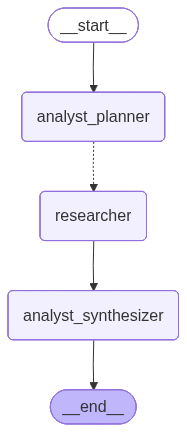

In [5]:
from IPython.display import Image, display

try:
    display(Image(graph.get_graph().draw_mermaid_png()))
except Exception as e:
    print(f"Could not display graph: {e}")

## 6. Execution

Run the graph tailored to a specific topic. The execution streams updates as researchers finish their tasks.

In [6]:
topic = "The Future of Indian Economy and Stock Market"
print(f"Starting execution for topic: {topic}")
print("-" * 50)

# Run the graph in a stream
# Note: In a notebook, we can just use 'await' directly
async for event in graph.astream({"topic": topic}, stream_mode="updates"):
    for key, value in event.items():
        if key == "researcher":
            # Print a small indicator that a researcher finished
            findings = value.get("findings", [""])[0]
            snippet = findings.replace("\n", " ")[:100]
            print(f"Researcher completed: {snippet}...")
        elif key == "analyst_synthesizer":
            print("\n" + "=" * 50)
            print("FINAL REPORT")
            print("=" * 50)
            print(value["report"])

Starting execution for topic: The Future of Indian Economy and Stock Market
--------------------------------------------------
--- Planning research for: The Future of Indian Economy and Stock Market ---
--- Investigating: Future trends in Indian economy 2024 ---
--- Investigating: Impact of government policies on Indian stock market ---
--- Investigating: Predictions for Indian stock market growth in the next decade ---
Researcher completed: Source (Predictions for Indian stock market growth in the next decade): India's stock market has bee...
Researcher completed: Source (Future trends in Indian economy 2024): 1 day ago - Machinery and equipment market is expecte...
Researcher completed: Source (Impact of government policies on Indian stock market): 12 hours ago - STT tax hike: Followin...
--- Synthesizing Report ---

FINAL REPORT
**Comprehensive Report on the Future of the Indian Economy and Stock Market**

**Executive Summary:**
The Indian economy is poised for significant growth i